In [14]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/transmission_extraction_aug_2026.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)
results["Score"] = results["score"].str.strip()

In [4]:
results["Score"].value_counts()

Score
Correct (DNE)                               358
Correct (Exists)                             12
Intern value wrong, LLM correct (Exists)     11
Intern value wrong, LLM correct (DNE)         9
Value exists but LLM did not find             5
Value exists but LLM got it wrong             1
Name: count, dtype: int64

In [5]:
len(
    results.groupby(["State", "County", "Jurisdiction Type"])
)

17

In [6]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)", "Intern value wrong, LLM correct (DNE)"
    },
    "exists_report": {
        "Correct (Exists)", "Intern value wrong, LLM correct (Exists)"
    },
    "dne_report": {
        "Value does not exist but LLM reported it"
    },
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

# Categories where the ordinance value truly exists.
EXIST_CATS = (
    score_cats["exists_report"]
    | score_cats["exists_bad_report"]
    | score_cats["exists_no_report"]
)

truth_labels_col = "ordinance_exists"
score_col = "llm_score"

results[score_col] = results["Score"].map(score_cats)
results[truth_labels_col] = results["Score"].isin(EXIST_CATS).astype(int)

In [7]:
out = compute_stats(
    results,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[ 23   6]
 [  0 413]]
accuracy=88.24%, precision=95.83%, recall=79.31%, F1=86.79%


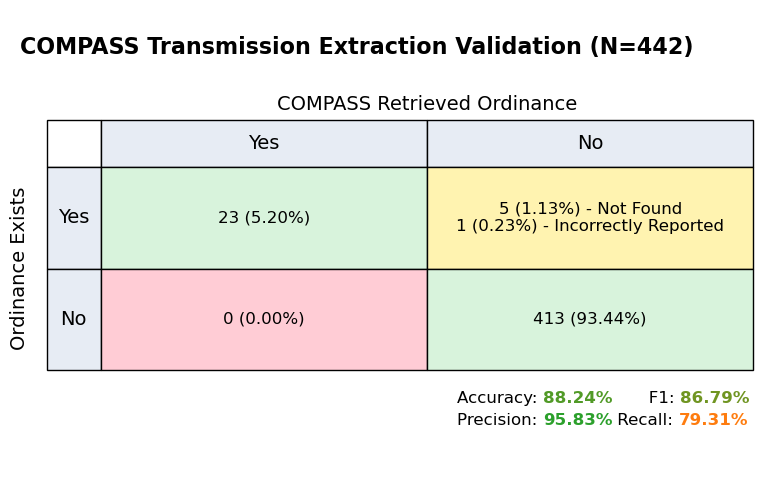

In [8]:
plot_compass_confusion_matrix_from_data(
    results,
    score_cats,
    title="COMPASS Transmission Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "transmission_validation_all_ordinances.png",
    color_scores=True,
)

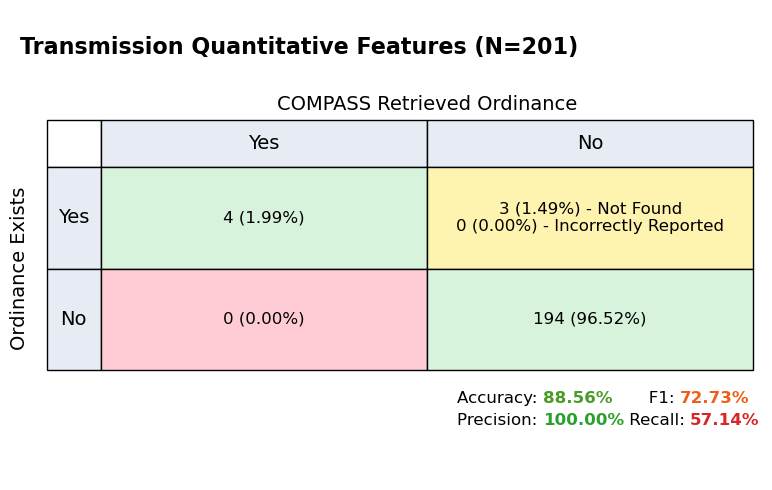

In [9]:
quant_fields = {
    "structures Distance",
    "residential buildings distance",
    "property line distance",
    "roads distance",
    "airport distance",
    "OHMW distance",
    "railroads distance",
    "voltage threshold",
    "electric field threshold",
    "maximum tower height",
    "maximum structure height",
    "noise",
}

plot_compass_confusion_matrix_from_data(
    results[results["Feature"].isin(quant_fields)],
    score_cats,
    title="Transmission Quantitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "transmission_quant.png",
    color_scores=True,
)

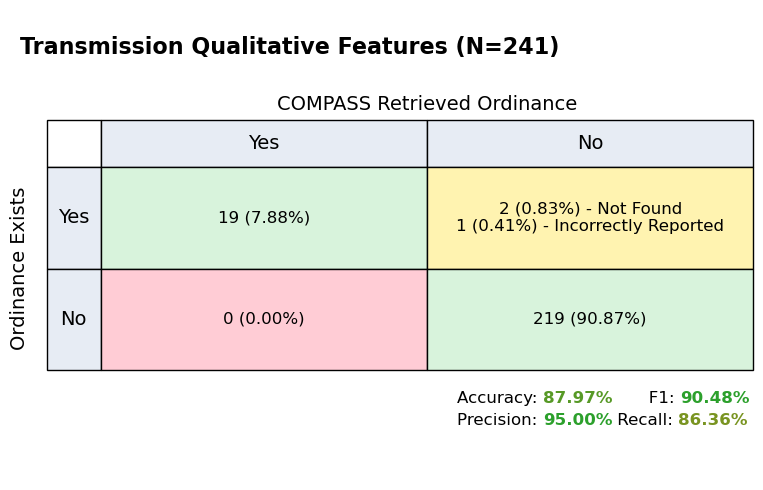

In [10]:
plot_compass_confusion_matrix_from_data(
    results[~results["Feature"].isin(quant_fields)],
    score_cats,
    title="Transmission Qualitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "transmission_qual.png",
    color_scores=True,
)

In [13]:
all_stats = []
for feature in results["Feature"].unique():
    data = results[results["Feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data[truth_labels_col].sum()
    num_found = (
        data["Score"].isin(
            score_cats["exists_report"]
            | score_cats["exists_bad_report"]
            | score_cats["dne_report"]
        )
    ).sum()
    num_found_correctly = (
        data["Score"].isin(score_cats["exists_report"])
    ).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metric

,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,structures Distance,88.235294,0.0,0.000000,0,0,0
1,residential buildings distance,88.235294,100.0,50.000000,2,1,1
2,property line distance,88.235294,100.0,100.000000,1,1,1
3,roads distance,88.235294,0.0,0.000000,0,0,0
4,airport distance,94.117647,0.0,0.000000,0,0,0
5,OHMW distance,100.000000,0.0,0.000000,0,0,0
6,railroads distance,100.000000,0.0,0.000000,0,0,0
7,voltage threshold,64.705882,100.0,50.000000,4,2,2
8,electric field threshold,100.000000,0.0,0.000000,0,0,0
9,maximum tower height,71.428571,0.0,0.000000,0,0,0


/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


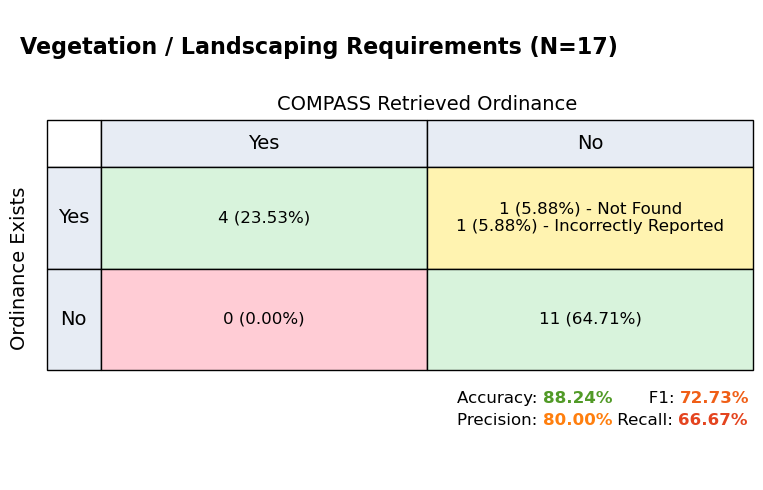

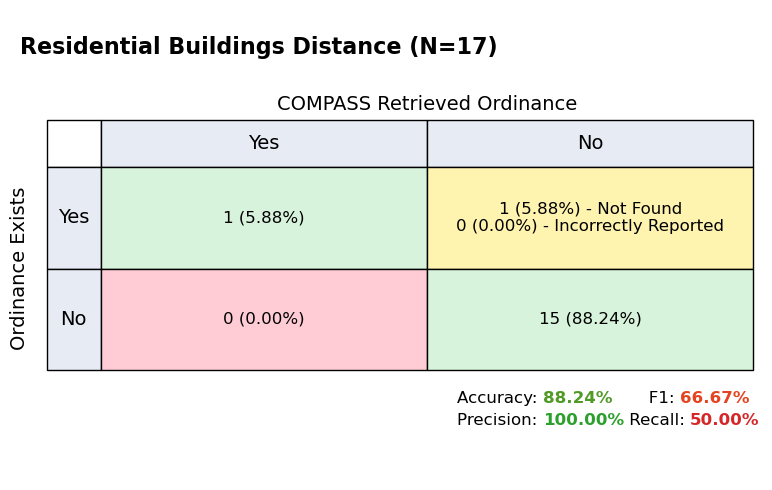

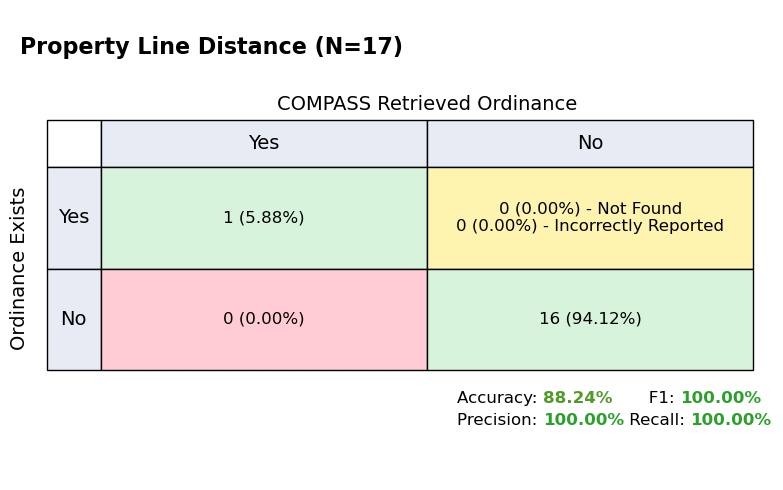

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metric

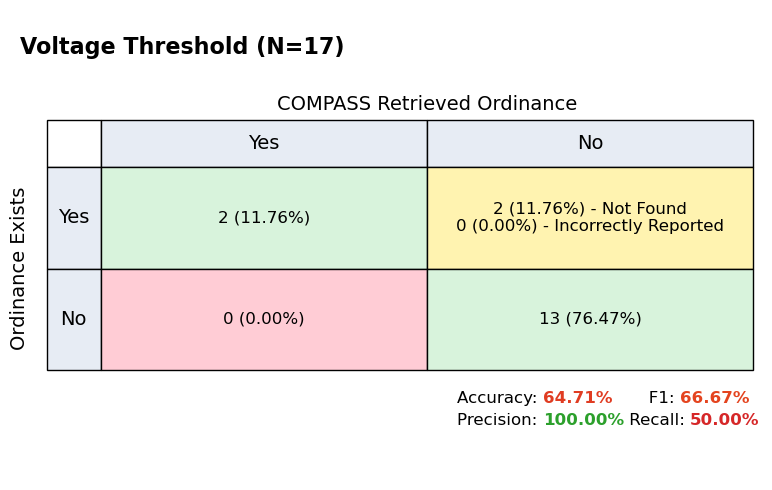

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metric

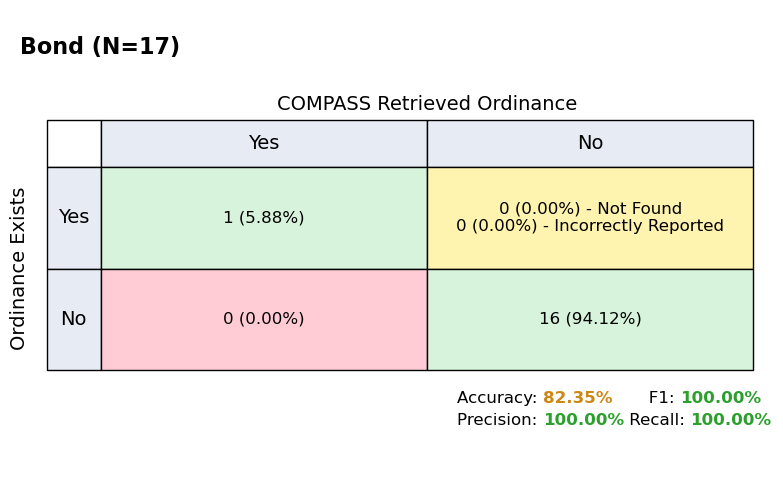

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


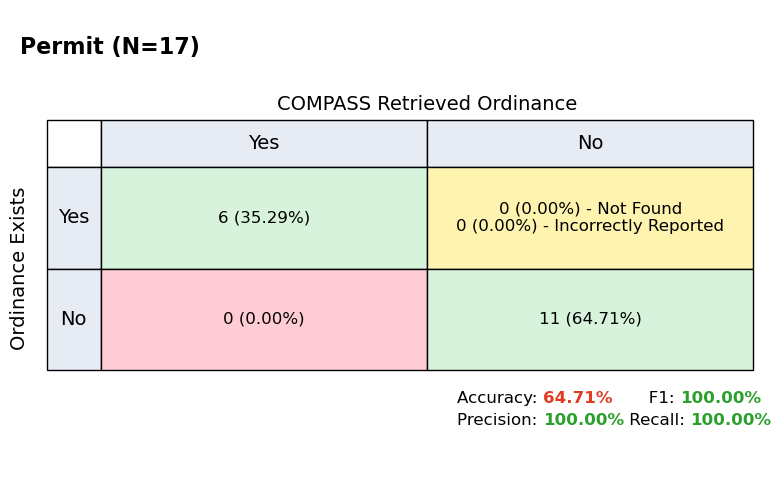

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


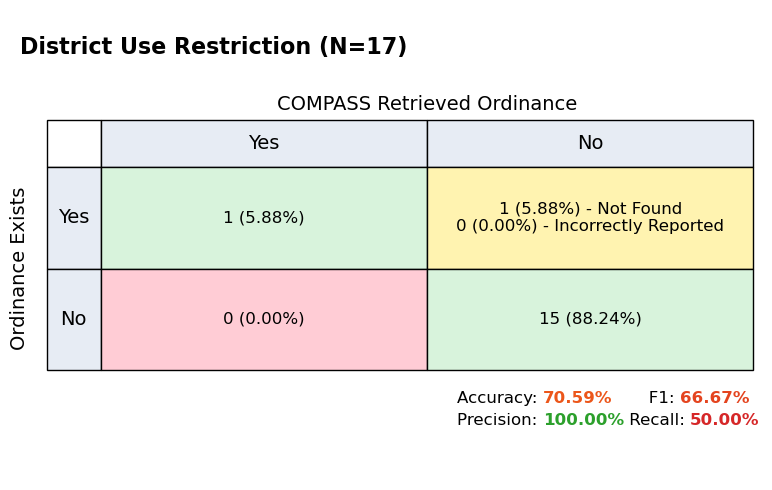

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metric

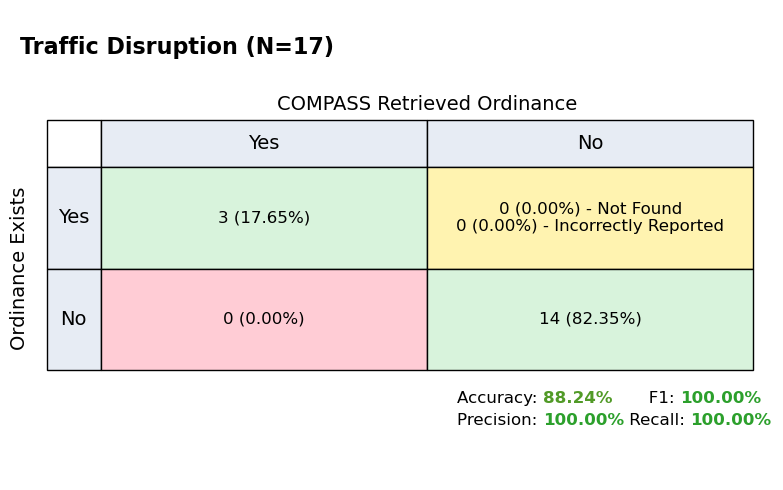

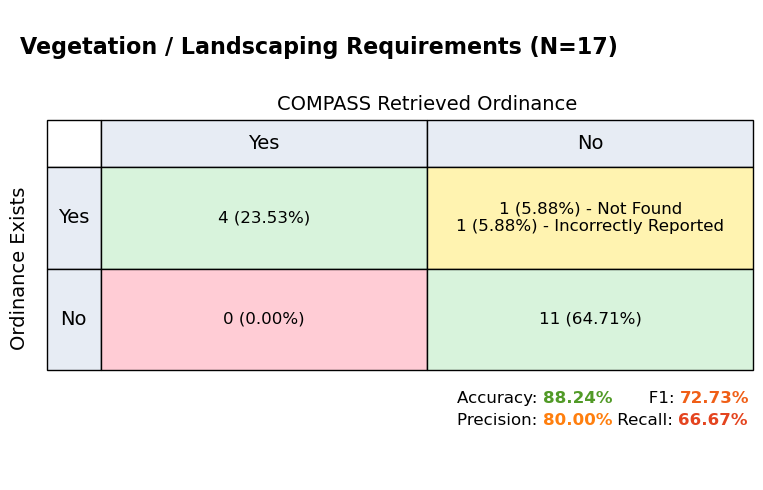

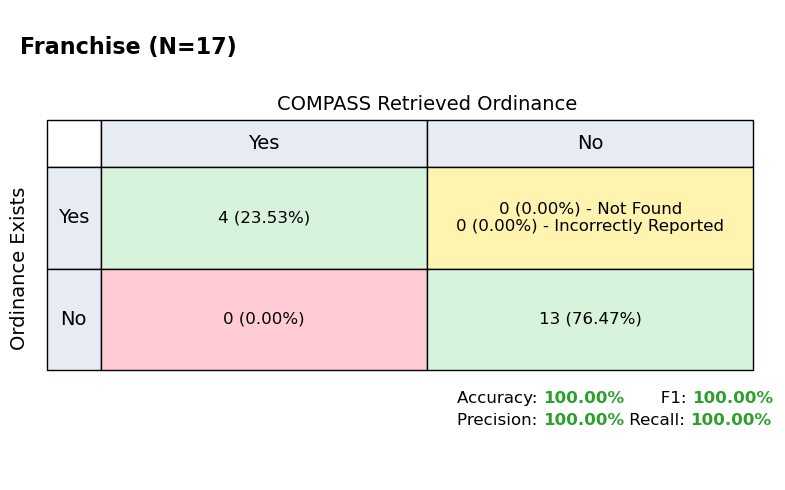

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [17]:
for feature in results["Feature"].unique():
    data = results[results["Feature"] == feature]
    plot_out_fn = f"solar_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn
        .replace(" / ", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )